# Lab 5: Linear Regression through Gradient Descent

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## Task 1: Load the Dataset

In [3]:
df = pd.read_csv('student_data/student-mat.csv', sep=';')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Task 2: Data Preprocessing

In [5]:
print("Total missing values:", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())

Total missing values: 0
Number of duplicate rows: 0


The columns fall into three groups that each need different handling:
- Binary categorical - map to 0/1.
- Nominal categorical with more than 2 categories - one-hot encode, since these have no natural order.

In [6]:
binary_maps = {
    'school': {'GP': 0, 'MS': 1},
    'sex': {'F': 0, 'M': 1},
    'address': {'U': 0, 'R': 1},
    'famsize': {'LE3': 0, 'GT3': 1},
    'Pstatus': {'A': 0, 'T': 1},
}
yes_no_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

df_enc = df.copy()
for col, mapping in binary_maps.items():
    df_enc[col] = df_enc[col].map(mapping)
for col in yes_no_cols:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0})

nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)
df_enc = df_enc.astype(float)

print("Shape after encoding:", df_enc.shape)
df_enc.head()

Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0.0,0.0,18.0,0.0,1.0,0.0,4.0,4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,17.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,15.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,15.0,0.0,1.0,1.0,4.0,2.0,1.0,3.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,16.0,0.0,1.0,1.0,3.0,3.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Task 3: Feature and Target Selection

In [7]:
X = df_enc.drop(columns='G3')
y = df_enc['G3']

print("Number of input features:", X.shape[1])
print("Target variable: G3 (final grade, 0-20)")
print(y.describe())

Number of input features: 41
Target variable: G3 (final grade, 0-20)
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


## Task 4: Train-Test Split

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

y_train = y_train.values.astype(float)
y_test = y_test.values.astype(float)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (316, 41)  Test shape: (79, 41)


## Task 5: Linear Regression via Gradient Descent (from scratch)

In [9]:
class GDLinearRegression:
    """Linear Regression trained with batch Gradient Descent on the MSE loss."""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            loss = np.mean(error ** 2) / 2   # MSE / 2, standard GD cost
            self.loss_history.append(loss)

            dw = (X.T @ error) / n_samples
            db = np.mean(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

## Task 6: Experimenting with Learning Rates

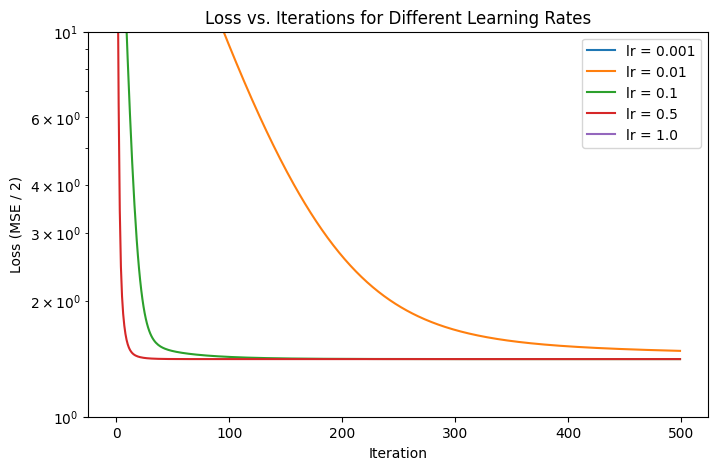

In [10]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
n_iterations = 500
lr_histories = {}

np.seterr(over='ignore', invalid='ignore')   # lr = 1.0 is expected to overflow while diverging
for lr in learning_rates:
    model = GDLinearRegression(learning_rate=lr, n_iterations=n_iterations)
    model.fit(X_train, y_train)
    lr_histories[lr] = model.loss_history

plt.figure()
for lr, history in lr_histories.items():
    plt.plot(history, label=f'lr = {lr}')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE / 2)')
plt.title('Loss vs. Iterations for Different Learning Rates')
plt.yscale('log')
plt.legend()
plt.show()

In [11]:
final_losses = {lr: history[-1] for lr, history in lr_histories.items()}
for lr, loss in final_losses.items():
    status = "diverged/unstable" if not np.isfinite(loss) or loss > lr_histories[lr][0] else "converged"
    print(f"lr = {lr:<6} final loss = {loss:>14.4f}   ({status})")

lr = 0.001  final loss =        22.7214   (converged)
lr = 0.01   final loss =         1.4827   (converged)
lr = 0.1    final loss =         1.4115   (converged)
lr = 0.5    final loss =         1.4115   (converged)
lr = 1.0    final loss =            inf   (diverged/unstable)


**Observation:**
- **lr = 0.001** decreases the loss too slowly - after 500 iterations it is still far from convergence.
- **lr = 0.01** converges smoothly and steadily to a low loss.
- **lr = 0.1** and **lr = 0.5** converge fastest among the stable rates, reaching the lowest loss within a small number of iterations.
- **lr = 1.0** is too large: each update overshoots the minimum by more and more, so the loss explodes instead of decreasing (diverges).

Based on this, **lr = 0.1** is chosen for the final model as it gives fast, stable convergence with a comfortable safety margin below the divergence threshold.

## Task 7: Final Model Training

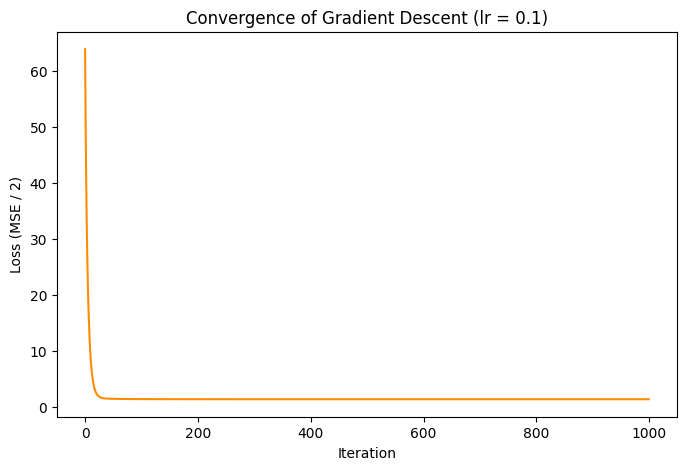

Final training loss after 1000 iterations: 1.4115


In [12]:
best_lr = 0.1
n_iterations_final = 1000

final_model = GDLinearRegression(learning_rate=best_lr, n_iterations=n_iterations_final)
final_model.fit(X_train, y_train)

plt.figure()
plt.plot(final_model.loss_history, color='darkorange')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE / 2)')
plt.title(f'Convergence of Gradient Descent (lr = {best_lr})')
plt.show()

print(f"Final training loss after {n_iterations_final} iterations: {final_model.loss_history[-1]:.4f}")

## Task 8: Model Evaluation

In [13]:
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 1.6467
MSE  : 5.6567
RMSE : 2.3784
R2   : 0.7241


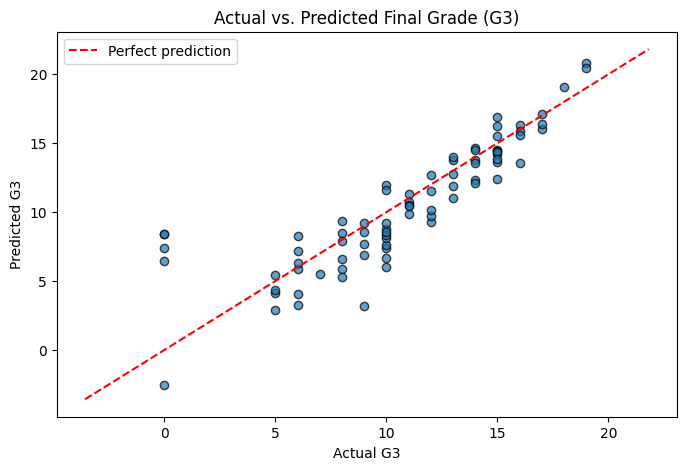

In [14]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs. Predicted Final Grade (G3)')
plt.legend()
plt.show()

### Sanity Check Against scikit-learn


In [15]:
sk_model = SklearnLinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Gradient Descent': [
        mae, mse, rmse, r2
    ],
    'scikit-learn (OLS)': [
        mean_absolute_error(y_test, y_pred_sk),
        mean_squared_error(y_test, y_pred_sk),
        np.sqrt(mean_squared_error(y_test, y_pred_sk)),
        r2_score(y_test, y_pred_sk),
    ]
})
comparison

,Metric,Gradient Descent,scikit-learn (OLS)
0,MAE,1.646677,1.646666
1,MSE,5.656668,5.656643
2,RMSE,2.378375,2.378370
3,R2,0.724133,0.724134


 The Gradient Descent model's metrics are very close to OLS solution, confirming that the gradient descent implementation has produced the same optimum.

## Task 9: Effect of Prior Grades (G1, G2) on Prediction

In [16]:
X_no_grades = X.drop(columns=['G1', 'G2'])
X_train_ng_raw, X_test_ng_raw, _, _ = train_test_split(
    X_no_grades, y, test_size=0.2, random_state=42)

scaler_ng = StandardScaler()
X_train_ng = scaler_ng.fit_transform(X_train_ng_raw)
X_test_ng = scaler_ng.transform(X_test_ng_raw)

model_ng = GDLinearRegression(learning_rate=best_lr, n_iterations=n_iterations_final)
model_ng.fit(X_train_ng, y_train)
y_pred_ng = model_ng.predict(X_test_ng)

r2_ng = r2_score(y_test, y_pred_ng)
rmse_ng = np.sqrt(mean_squared_error(y_test, y_pred_ng))

print("Without G1, G2 as features:")
print(f"  R2   : {r2_ng:.4f}")
print(f"  RMSE : {rmse_ng:.4f}")
print()
print("With G1, G2 as features:")
print(f"  R2   : {r2:.4f}")
print(f"  RMSE : {rmse:.4f}")

Without G1, G2 as features:
  R2   : 0.1415
  RMSE : 4.1957

With G1, G2 as features:
  R2   : 0.7241
  RMSE : 2.3784


Removing the prior period grades G1 and G2 causes R2 to drop sharply and RMSE to rise. A student's final grade is strongly correlated with their performance earlier in the year.

## Interpretation and Conclusion

Gradient descent worked as expected: too small a learning rate (0.001) barely moved the loss, too large (1.0) made it blow up to infinity, and something in between (0.1) converged fast and stayed stable. The final model got a decent R2 of about 0.72, and matched scikit-learn's built-in LinearRegression almost exactly, so the from-scratch implementation checks out. Also, G1 and G2 turned out to be doing most of the work - drop them and R2 falls to about 0.14, meaning a student's earlier grades predict their final grade far better than any of the demographic or social features do.